**Principal Component Analysis**

Perform Principal Component Analysis (PCA) to understand how it can help in visualizing high-dimensional gene expression data, as illustrated in the Nature Primer on unsupervised learning.

You are provided with the following dataset:

*   data/class.tsv: Contains class labels for 105 patient samples — 1 for ER+ breast cancer and 0 for ER- breast cancer.
*   data/filtered.tsv.gz: Gene expression matrix for all patients. Each row represents a sample, and each column corresponds to a gene (identified by an ID).
*   data/columns.tsv.gz: A mapping file from gene ID to gene name.

Your goal is to:


*   Gene-level Scatter Plot (Figure 1a)
Extract the expression values for the genes XBP1 and GATA3 across all 105 patients.

  Plot these as a 2D scatter plot where:

  The x-axis is GATA3 expression.
  The y-axis is XBP1 expression.
  Points are colored by their class label (ER+ or ER-).

  Your plot should resemble Figure 1a from the Primer (patterns may slightly vary due to data scale, but clustering trend should be visible).
*   PCA Projection (Figure 1c)

  Perform Principal Component Analysis (PCA) on the full expression dataset.Project the data onto the first principal component (PC1).

  Plot each sample as a point on a 1D line (i.e., PC1 values), again color-coded by class label.

  Your plot should resemble Figure 1c from the Primer, showing clear separation along PC1.






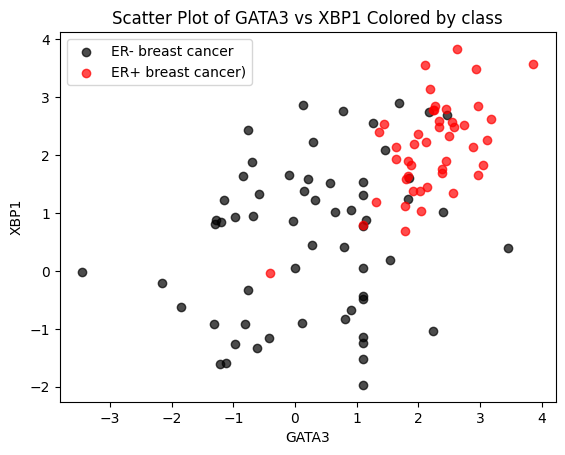

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

df0 = pd.read_csv("/mnt/filtered.tsv", sep="\t")
df1 = pd.read_csv("/mnt/class.tsv", sep="\t", header=None)
df2 = pd.read_csv("/mnt/columns.tsv", sep="\t", comment="#")

x1 = (df2.loc[df2['GeneSymbol'] == 'GATA3', 'ID'].values[0])
y1 = df2.loc[df2['GeneSymbol'] == 'XBP1', 'ID'].values[0]

x1 = " " + str(x1)
y1 = " " + str(y1)

x = df0[x1].values
y = df0[y1].values
z = df1[0].values

m0 = (z == 0)
m1 = (z == 1)

plt.scatter(x[m0], y[m0], color='black', alpha=0.7, label='ER- breast cancer')
plt.scatter(x[m1], y[m1], color='red', alpha=0.7, label='ER+ breast cancer)')

plt.xlabel("GATA3")
plt.ylabel("XBP1")
plt.title("Scatter Plot of GATA3 vs XBP1 Colored by class")
plt.legend()
plt.show()

[3.07186142 0.87054073]


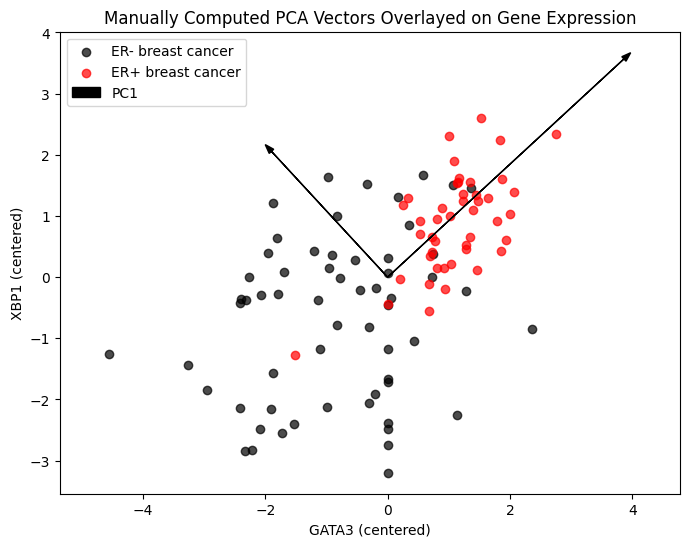

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

x_vals = x
y_vals = y
z_vals = z

data = np.vstack((x_vals, y_vals)).T
mean = np.mean(data, axis=0)
data_centered = (data - mean)

cov_mat = np.cov(data_centered.T)

eig_vals, eig_vecs = np.linalg.eig(cov_mat)

print(eig_vals)
sorted_ind = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[sorted_ind]
eig_vecs = eig_vecs[:, sorted_ind]

comp = eig_vecs.T
exp = eig_vals

m0 = (z_vals == 0)
m1 = (z_vals == 1)

plt.figure(figsize=(8, 6))
plt.scatter(data_centered[m0, 0], data_centered[m0, 1], color='black', alpha=0.7, label='ER- breast cancer')
plt.scatter(data_centered[m1, 0], data_centered[m1, 1], color='red', alpha=0.7, label='ER+ breast cancer')

for i in range(2):
    plt.arrow(0, 0, comp[i, 0] * np.sqrt(exp[i]) * 3, comp[i, 1] * np.sqrt(exp[i]) * 3,
              color='black', width=0.001, head_width=0.1, label=f'PC{i+1}' if i == 0 else None)

plt.xlabel("GATA3 (centered)")
plt.ylabel("XBP1 (centered)")
plt.title("Manually Computed PCA Vectors Overlayed on Gene Expression")
plt.legend()
plt.axis('equal')
plt.show()

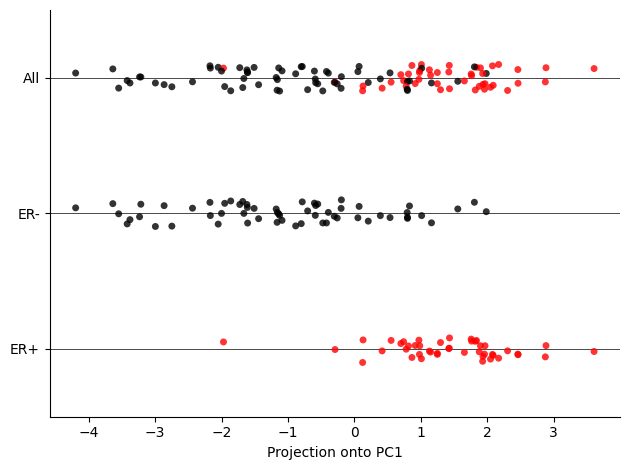

In [22]:
pc1_vector = eig_vecs[:, 0]
pc1_projection = data_centered @ pc1_vector

df_all = pd.DataFrame({"PC1": pc1_projection, "Group": "All", "Color": np.where(z == 0, "black", "red")})
df_er_minus = pd.DataFrame({"PC1": pc1_projection[z == 0], "Group": "ER-", "Color": "black"})
df_er_plus = pd.DataFrame({"PC1": pc1_projection[z == 1], "Group": "ER+", "Color": "red"})

plot_df = pd.concat([df_all, df_er_minus, df_er_plus], ignore_index=True)

ax = sns.stripplot(data=plot_df, x="PC1", y="Group", hue="Color", palette={"black": "black", "red": "red"}, dodge=False, jitter=True, alpha=0.8, size=5)

ax.yaxis.grid(True, linestyle='-', color='black', linewidth=0.5, alpha=1.0)

plt.xlabel("Projection onto PC1")
plt.ylabel("")
plt.legend([], [], frameon=False)
sns.despine()
plt.tight_layout()
plt.show()